In [1]:
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats

In [2]:
az.style.use("arviz-darkgrid")

## Non-Markovian methods

### Grid computing

In [3]:
def posterior_grid(grid_points=50, heads=6, tails=9):
    """
    A grid implementation for the coin-flipping problem
    """
    grid = np.linspace(0, 1, grid_points)
    prior = np.repeat(1 / grid_points, grid_points)
    likelihood = stats.binom.pmf(heads, heads + tails, grid)
    posterior = likelihood * prior
    posterior = posterior / posterior.sum()
    return (grid, posterior)

Assuming we flip a coin 13 times and we observed 3 head we have:

[Text(0.5, 1.0, 'heads = 3, tails = 10'), [], Text(0.5, 0, 'θ')]

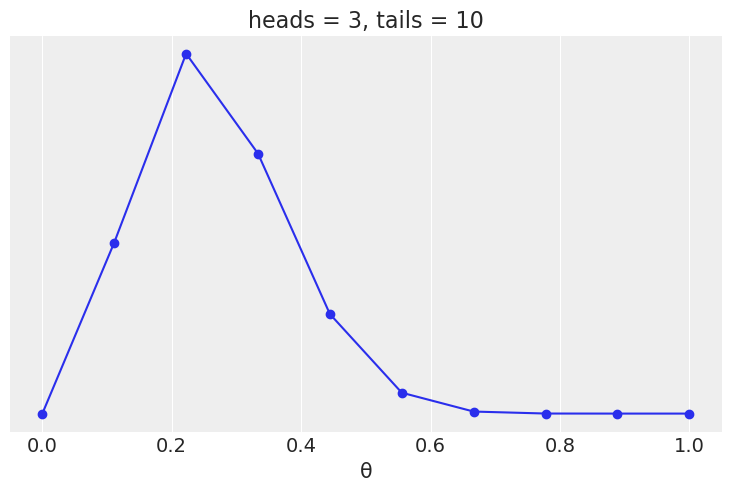

In [4]:
points = 10
data = np.repeat([0, 1], (10, 3))
h = data.sum()
t = len(data) - h
grid, posterior = posterior_grid(points, h, t)
_, ax = plt.subplots()
ax.plot(grid, posterior, "o-")
ax.set(title=f"heads = {h}, tails = {t}", yticks=[], xlabel="θ")

### Quadratic method

In [5]:
with pm.Model() as normal_approx:
    p = pm.Beta("p", 1.0, 1.0)
    w = pm.Binomial("w", n=1, p=p, observed=data)
    mean_q = pm.find_MAP()
    std_q = ((1 / pm.find_hessian(mean_q, vars=[p])) ** 0.5)[0]

mean_q["p"], std_q

Output()

/Users/integzz/.conda/envs/kaggle/lib/python3.12/site-packages/pytensor/configparser.py:44: FutureWarning: hessian will stop negating the output in a future version of PyMC.
To suppress this warning set `negate_output=False`
  return f(*args, **kwargs)


(array(0.23076923), array([0.61282588]))

[Text(0.5, 1.0, 'heads = 3, tails = 10'), [], Text(0.5, 0, 'θ')]

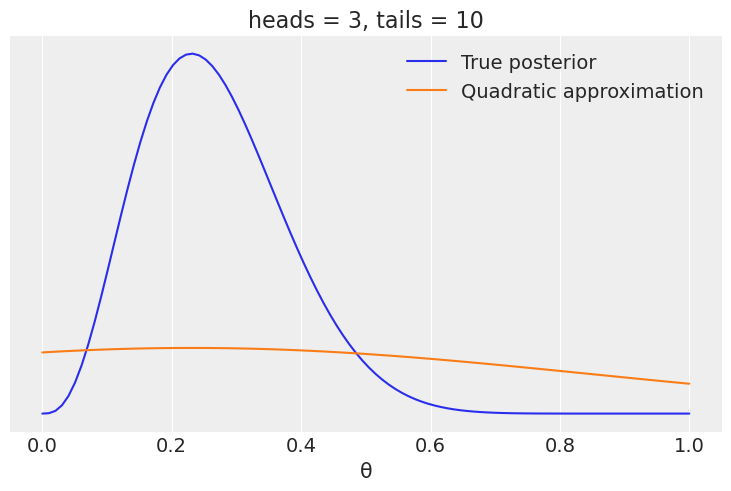

In [6]:
_, ax1 = plt.subplots()
x1 = np.linspace(0, 1, 100)
ax1.plot(x1, stats.beta.pdf(x1, h + 1, t + 1), label="True posterior")
ax1.plot(x1, stats.norm.pdf(x1, mean_q["p"], std_q), label="Quadratic approximation")
ax1.legend(loc=0)
ax1.set(title=f"heads = {h}, tails = {t}", yticks=[], xlabel="θ")

## Markovian methods

### Monte Carlo

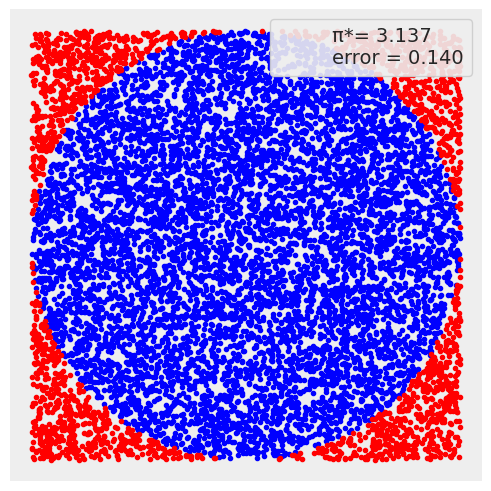

In [7]:
N = 10000
x, y = np.random.uniform(-1, 1, size=(2, N))
inside = x**2 + y**2 <= 1
π = inside.sum() * 4 / N
err = abs((π - np.pi) / π) * 100
outside = np.invert(inside)
_, ax2 = plt.subplots()
ax2.plot(x[inside], y[inside], "b.")
ax2.plot(x[outside], y[outside], "r.")
ax2.plot(0, 0, label=f"π*= {π:4.3f}\nerror = {err:4.3f}", alpha=0)
ax2.axis("square")
ax2.set(xticks=[], yticks=[])
ax2.legend(loc=1, frameon=True, framealpha=0.9)

In [8]:
def metropolis(func, draws=10000):
    """A very simple Metropolis implementation"""
    trace = np.zeros(draws)
    old_x = 0.5  # func.mean()
    old_prob = func.pdf(old_x)

    delta = np.random.normal(0, 0.5, draws)
    for i in range(draws):
        new_x = old_x + delta[i]
        new_prob = func.pdf(new_x)
        acceptance = new_prob / old_prob
        if acceptance >= np.random.random():
            trace[i] = new_x
            old_x = new_x
            old_prob = new_prob
        else:
            trace[i] = old_x

    return trace

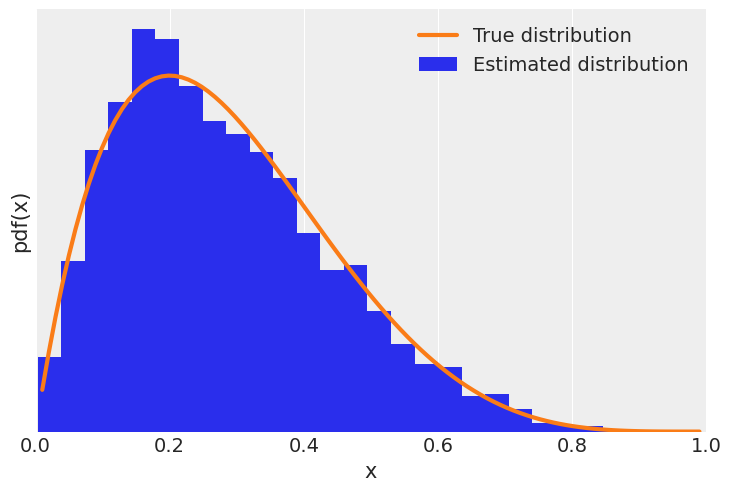

In [9]:
np.random.seed(3)
func = stats.beta(2, 5)
trace = metropolis(func=func)
x_metro = np.linspace(0.01, 0.99, 100)
y_metro = func.pdf(x_metro)
_, ax3 = plt.subplots()
ax3.plot(x_metro, y_metro, "C1-", lw=3, label="True distribution")
ax3.hist(trace[trace > 0], bins=25, density=True, label="Estimated distribution")
ax3.set(xlabel="x", ylabel="pdf(x)", yticks=[], xlim=(0, 1))
ax3.legend()

## Diagnosing the samples

In [10]:
path = "../../book-prob-tmp/bap-10-sample-centered.nc"

with pm.Model() as centered_model:
    a = pm.HalfNormal("a", 10)
    b = pm.Normal("b", 0, a, shape=10)
    if os.path.isfile(path):
        idata_cm = az.from_netcdf(path)
    else:
        idata_cm = pm.sample(2000, random_seed=7)
        idata_cm.to_netcdf(path)

path = "../../book-prob-tmp/bap-10-sample-noncentered.nc"
with pm.Model() as non_centered_model:
    a = pm.HalfNormal("a", 10)

    b_offset = pm.Normal("b_offset", mu=0, sigma=1, shape=10)
    b = pm.Deterministic("b", 0 + b_offset * a)

    if os.path.isfile(path):
        idata_ncm = az.from_netcdf(path)
    else:
        idata_ncm = pm.sample(2000, random_seed=7)
        idata_ncm.to_netcdf(path)

array([[<Axes: title={'center': 'a'}>, <Axes: title={'center': 'a'}>]],
      dtype=object)

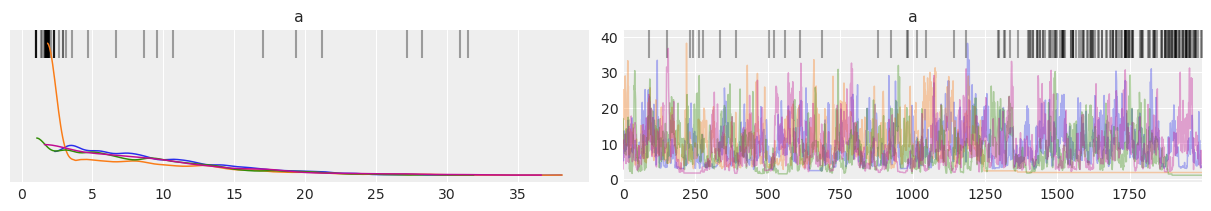

In [11]:
az.plot_trace(idata_cm, var_names=["a"], divergences="top", compact=False)
# plt.savefig("../images/bbap/bap-10-trace-cm.png")

array([[<Axes: title={'center': 'a'}>, <Axes: title={'center': 'a'}>]],
      dtype=object)

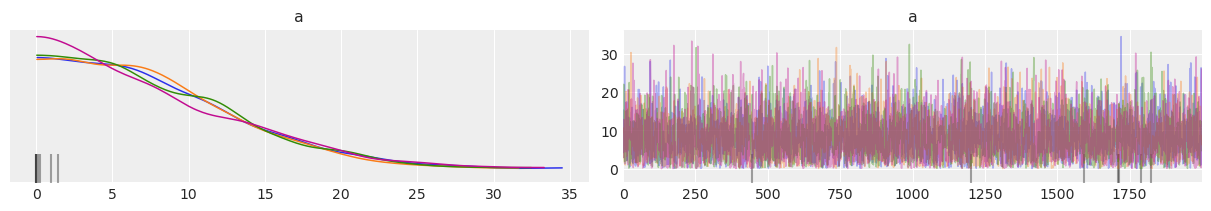

In [12]:
az.plot_trace(idata_ncm, var_names=["a"], compact=False)
# plt.savefig("../images/bbap/bap-10-trace-ncm.png")

In [13]:
az.rhat(idata_cm)["a"].to_numpy().flatten()

array([1.08902554])

array([<Axes: title={'center': '94.0% HDI'}>,
       <Axes: title={'center': 'ess'}>, <Axes: title={'center': 'r_hat'}>],
      dtype=object)

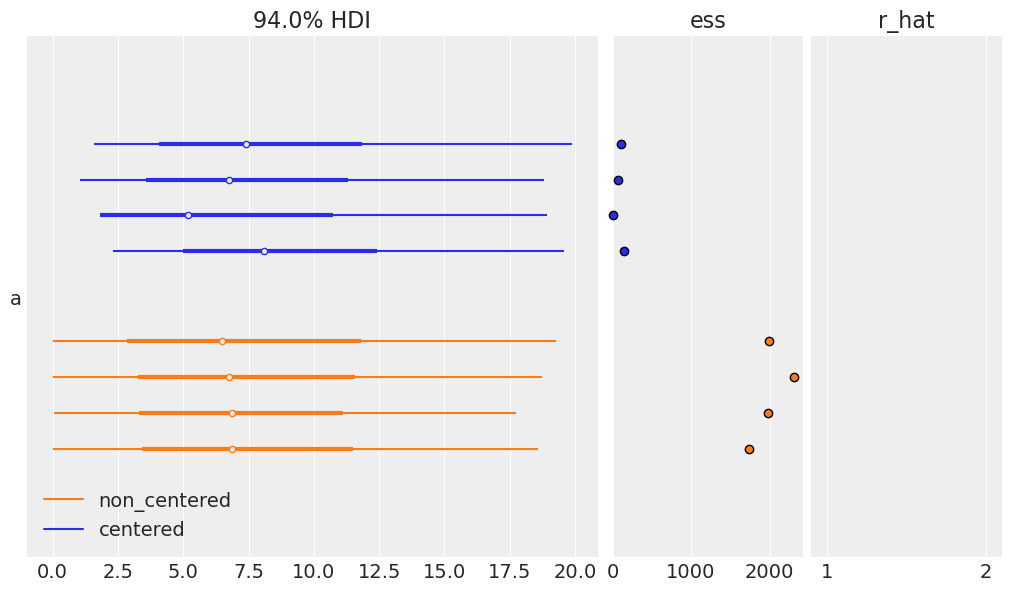

In [14]:
az.plot_forest(
    [idata_cm, idata_ncm],
    model_names=["centered", "non_centered"],
    var_names=["a"],
    r_hat=True,
    ess=True,
)

In [15]:
summaries = pd.concat([
    az.summary(idata_cm, var_names=["a"]),
    az.summary(idata_ncm, var_names=["a"]),
])
summaries.index = ["centered", "non_centered"]
# summaries.to_csv("./bap-10-hier-summary.csv")
summaries

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
centered,8.373,5.965,1.041,19.346,0.616,0.148,35.0,11.0,1.09
non_centered,7.926,5.878,0.003,18.504,0.065,0.067,6021.0,3820.0,1.00


<Axes: title={'center': 'a'}>

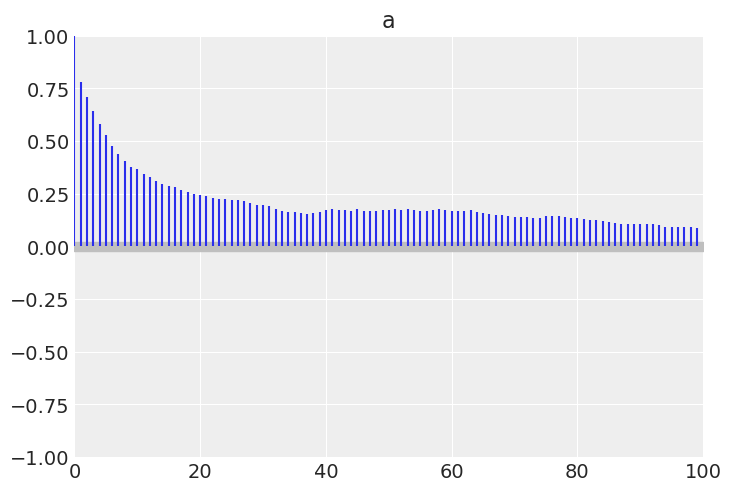

In [16]:
az.plot_autocorr(idata_cm, var_names=["a"], combined=True)
# plt.savefig("../images/bbap/bap-10-autocorr-cm.png")

<Axes: title={'center': 'a'}>

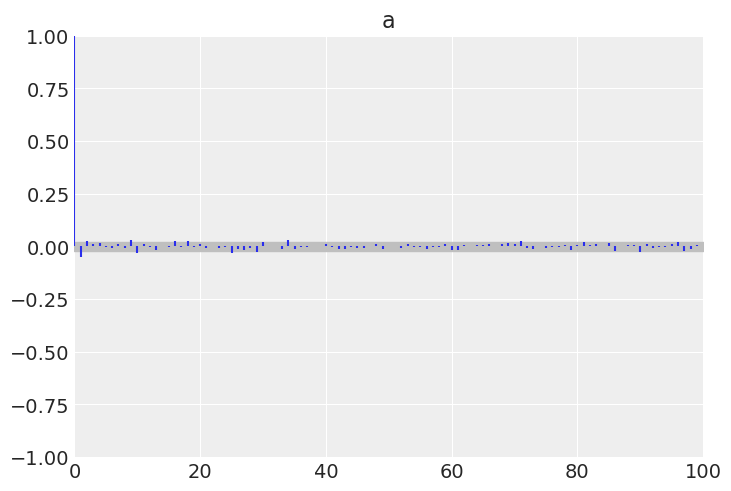

In [17]:
az.plot_autocorr(idata_ncm, var_names=["a"], combined=True)
# plt.savefig("../images/bbap/bap-10-autocorr-ncm.png")

## Effective sample size

In [18]:
az.ess(idata_cm)["a"].to_numpy().flatten()

array([34.57120725])

## Divergences

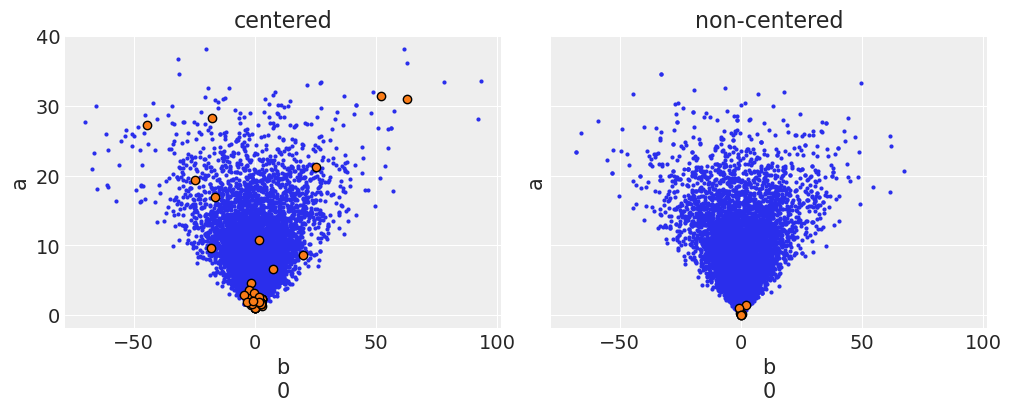

In [19]:
_, axes = plt.subplots(
    1, 2, sharey=True, sharex=True, figsize=(10, 4), constrained_layout=True
)
for tr, title, ax_dv in zip(
    [idata_cm, idata_ncm], ["centered", "non-centered"], axes.flatten(), strict=False
):
    az.plot_pair(
        tr,
        var_names=["b", "a"],
        coords={"b_dim_0": [0]},
        kind="scatter",
        divergences=True,
        divergences_kwargs={"color": "C1"},
        ax=ax_dv,
    )
    ax_dv.set(title=title)

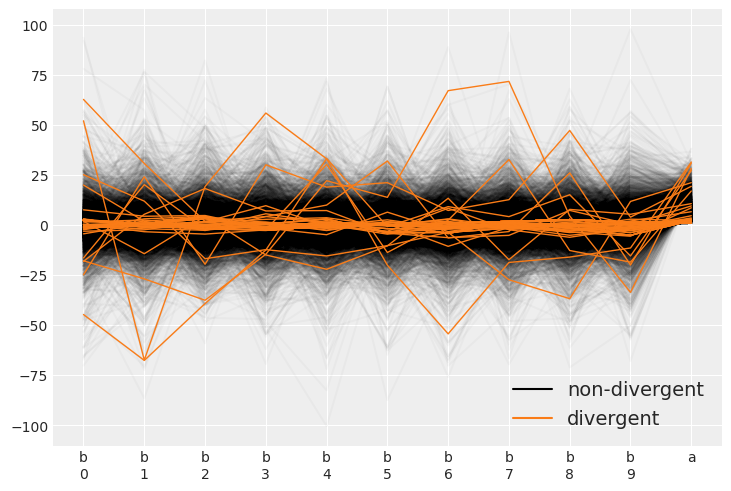

In [20]:
az.plot_parallel(idata_cm)
plt.legend(loc="lower right")
# plt.savefig("../images/bbap/bap-10-parallel-cm.png")

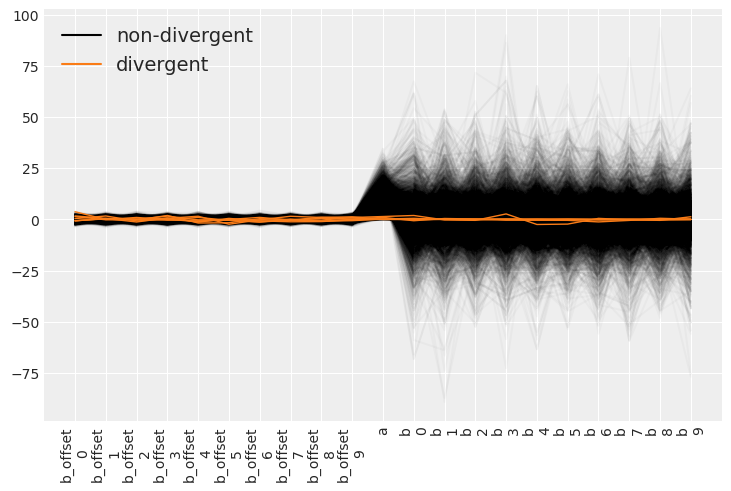

In [22]:
ax_dv2 = az.plot_parallel(idata_ncm)
plt.setp(ax_dv2.get_xticklabels(), rotation=90);